# **1- Libraries**

In [52]:
import numpy as np
import pandas as pd
import random
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from keras.models import Sequential
from keras.layers import LSTM, Dense, Conv1D, MaxPooling1D, Flatten, Dropout
from keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [53]:
seed = 42
random.seed(seed)
np.random.seed(seed)

# **2- Data preparation**

## **2-1- Data upload**

In [54]:
data = pd.read_csv('/content/Monthly_data.csv', sep=";")
data.head()

,index,MONTH,WOD,N-OS,OP,USD/DZD,GPR,PRICE
0,0,Jan-00,"75,58","45,8","26,5","68,232775","64,46","25,6"
1,1,Feb-00,NaN,NaN,NaN,"69,198775","63,54","26,3"
2,2,Mar-00,NaN,NaN,NaN,"72,134723","50,1","26,7"
3,3,Apr-00,"74,09","45,5","27,9","73,913208","48,68","26,5"
4,4,May-00,NaN,NaN,NaN,"76,018356","79,48","27,4"


In [55]:
data['MONTH'] = pd.to_datetime(data['MONTH'], format='%b-%y')
data.set_index('MONTH', inplace=True)

In [56]:
data = data.drop('index', axis=1)

## **2-2- Data cleaning**

### **2-2-1- Type conversion**

In [57]:
data['WOD'] = data['WOD'].str.replace(',', '.')
data['GPR'] = data['GPR'].str.replace(',', '.')
data['N-OS'] = data['N-OS'].str.replace(',', '.')
data['OP'] = data['OP'].str.replace(',', '.')
data['PRICE'] = data['PRICE'].str.replace(',', '.')
data['USD/DZD'] = data['USD/DZD'].str.replace(',', '.')

In [58]:
data['USD/DZD'] = data['USD/DZD'].astype(float)
data['GPR'] = data['GPR'].astype(float)
data['OP'] = data['OP'].astype(float)
data['N-OS'] = data['N-OS'].astype(float)
data['WOD'] = data['WOD'].astype(float)
data['PRICE'] = data['PRICE'].astype(float)

### **2-2-2- Handle NAs**

In [59]:
data.isnull().sum()

,0
WOD,184
N-OS,184
OP,182
USD/DZD,0
GPR,0
PRICE,0


In [60]:
data = data.fillna(method='ffill')
data

/tmp/ipykernel_376/2074418932.py:1: FutureWarning:

DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.



,WOD,N-OS,OP,USD/DZD,GPR,PRICE
MONTH,,,,,,
2000-01-01,75.58,45.80,26.50,68.232775,64.46,25.60
2000-02-01,75.58,45.80,26.50,69.198775,63.54,26.30
2000-03-01,75.58,45.80,26.50,72.134723,50.10,26.70
2000-04-01,74.09,45.50,27.90,73.913208,48.68,26.50
2000-05-01,74.09,45.50,27.90,76.018356,79.48,27.40
...,...,...,...,...,...,...
2022-08-01,99.44,65.55,29.41,142.450548,132.86,104.22
2022-09-01,99.44,65.55,29.41,140.559909,131.99,92.72
2022-10-01,101.17,66.84,29.11,140.263062,143.16,95.66


## **2-3- Outliers**

In [61]:
Q1 = data['PRICE'].quantile(0.25)
Q3 = data['PRICE'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = data[(data['PRICE'] < lower_bound) | (data['PRICE'] > upper_bound)]
outliers

,WOD,N-OS,OP,USD/DZD,GPR,PRICE
MONTH,,,,,,


In [62]:
# Calculate the Z-score for each data point
z_scores = np.abs((data['PRICE'] - data['PRICE'].mean()) / data['PRICE'].std())

# Identify outliers with Z-scores greater than 3 or less than -3
outliers = data[np.logical_or(z_scores > 3, z_scores < -3)]
print(outliers)

Empty DataFrame
Columns: [WOD, N-OS, OP, USD/DZD, GPR, PRICE]
Index: []


# **3- Descriptive Statistics**

## **3-1- Price over time**

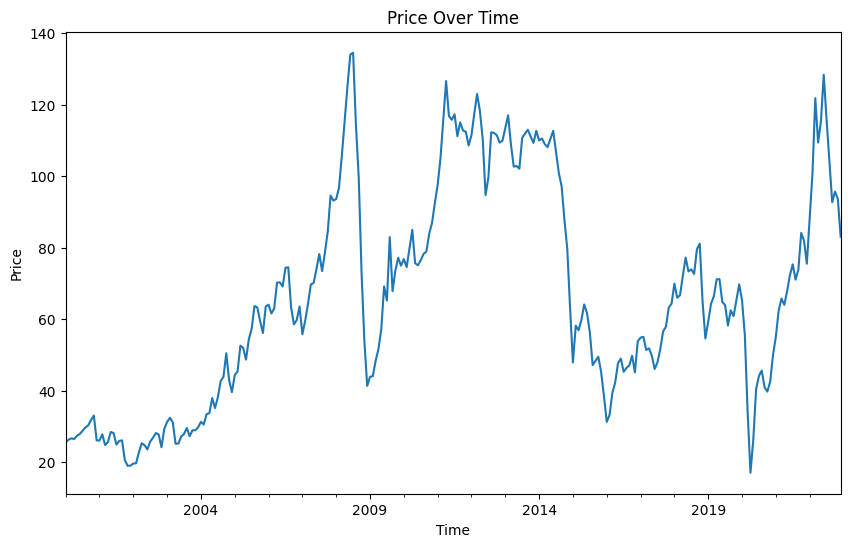

In [63]:
#plotting price over time-frame
data['PRICE'].plot(kind='line', figsize=(10, 6))
plt.xlabel('Time')
plt.ylabel('Price')
plt.title('Price Over Time')
plt.show()

## **3-2- Other variables over time**

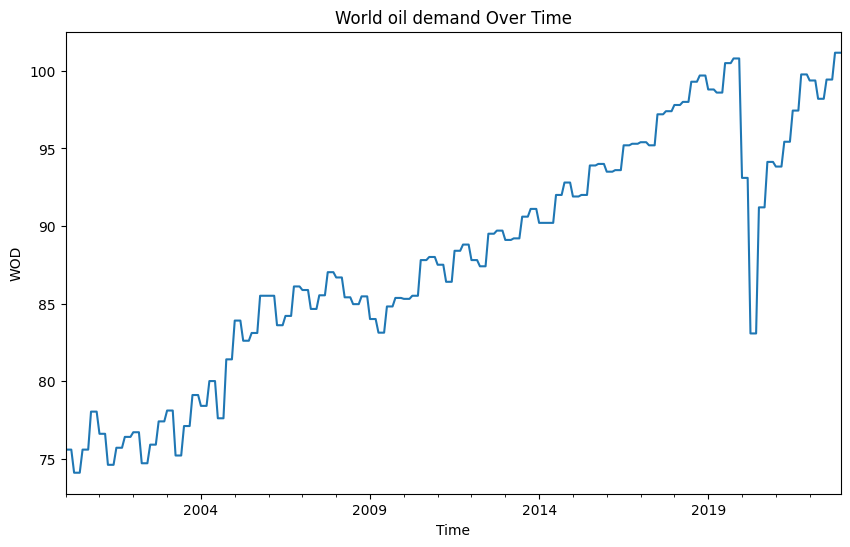

In [64]:
#plotting WOD over time-frame
data['WOD'].plot(kind='line', figsize=(10, 6))
plt.xlabel('Time')
plt.ylabel('WOD')
plt.title('World oil demand Over Time')
plt.show()

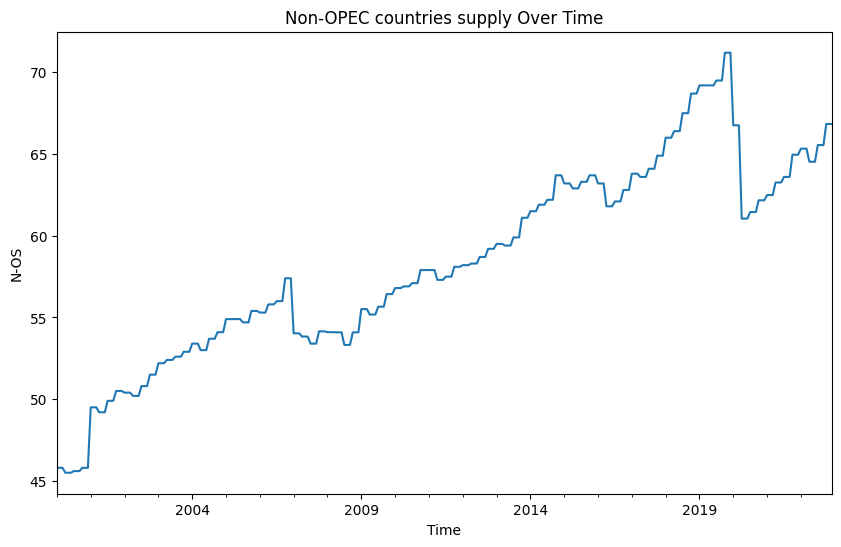

In [65]:
#plotting N-OS over time-frame
data['N-OS'].plot(kind='line', figsize=(10, 6))
plt.xlabel('Time')
plt.ylabel('N-OS')
plt.title('Non-OPEC countries supply Over Time')
plt.show()

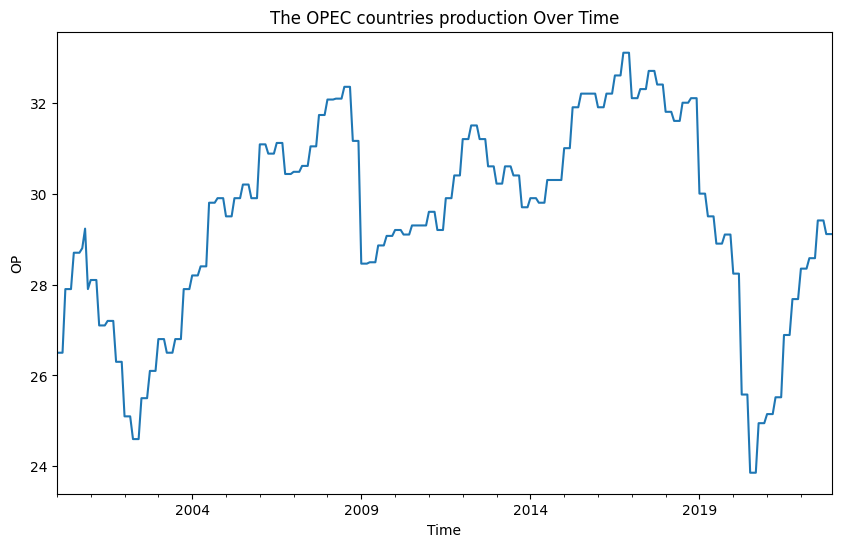

In [66]:
#plotting OP over time-frame
data['OP'].plot(kind='line', figsize=(10, 6))
plt.xlabel('Time')
plt.ylabel('OP')
plt.title('The OPEC countries production Over Time')
plt.show()

## **3-3- Oil price fluctuation over the years**

In [67]:
yearly_avg = data['PRICE'].resample('Y').mean().reset_index()
yearly_avg['YEAR'] = yearly_avg['MONTH'].dt.year

fig_yearly = px.line(
    yearly_avg,
    x='YEAR',
    y='PRICE',
    markers=True,
    title='Average Oil Price per Year'
)
fig_yearly.update_layout(xaxis_title='Year', yaxis_title='Average Oil Price')
fig_yearly.show()

/tmp/ipykernel_376/2484602147.py:1: FutureWarning:

'Y' is deprecated and will be removed in a future version, please use 'YE' instead.



## **3-4- Average oil price per month ( seasonality)**

In [68]:
monthly_avg = data.groupby(data.index.month)['PRICE'].mean().reset_index()
monthly_avg.columns = ['MONTH_NUM', 'PRICE']

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_avg['MONTH_NAME'] = monthly_avg['MONTH_NUM'].apply(lambda m: month_names[m - 1])

fig_monthly = px.bar(
    monthly_avg.sort_values('MONTH_NUM'),
    x='MONTH_NAME',
    y='PRICE',
    title='Average Oil Price by Month (all years combined)',
    text_auto='.2f'
)
fig_monthly.update_layout(xaxis_title='Month', yaxis_title='Average Oil Price')
fig_monthly.show()

## **3-5- GPR index vs Oil price**

In [69]:
# Monthly view - dual axis
fig_gpr_monthly = make_subplots(specs=[[{"secondary_y": True}]])

fig_gpr_monthly.add_trace(
    go.Scatter(x=data.index, y=data['PRICE'], name='Oil Price', line=dict(color='#1f77b4')),
    secondary_y=False
)
fig_gpr_monthly.add_trace(
    go.Scatter(x=data.index, y=data['GPR'], name='GPR Index', line=dict(color='#d62728')),
    secondary_y=True
)

fig_gpr_monthly.update_layout(title='Oil Price vs GPR Index Over Time')
fig_gpr_monthly.update_yaxes(title_text='Oil Price', secondary_y=False)
fig_gpr_monthly.update_yaxes(title_text='GPR Index', secondary_y=True)
fig_gpr_monthly.show()

In [70]:
# Yearly average view - combo chart, easier to spot the relationship
yearly_all = data.resample('Y').mean().reset_index()
yearly_all['YEAR'] = yearly_all['MONTH'].dt.year

fig_gpr_yearly = make_subplots(specs=[[{"secondary_y": True}]])

fig_gpr_yearly.add_trace(
    go.Bar(x=yearly_all['YEAR'], y=yearly_all['PRICE'], name='Avg Oil Price', marker_color='#1f77b4'),
    secondary_y=False
)
fig_gpr_yearly.add_trace(
    go.Scatter(x=yearly_all['YEAR'], y=yearly_all['GPR'], name='Avg GPR Index',
               line=dict(color='#d62728', width=3), mode='lines+markers'),
    secondary_y=True
)

fig_gpr_yearly.update_layout(title='Average Oil Price vs Average GPR Index per Year')
fig_gpr_yearly.update_yaxes(title_text='Avg Oil Price', secondary_y=False)
fig_gpr_yearly.update_yaxes(title_text='Avg GPR Index', secondary_y=True)
fig_gpr_yearly.show()

/tmp/ipykernel_376/4147806293.py:2: FutureWarning:

'Y' is deprecated and will be removed in a future version, please use 'YE' instead.



## **3-6- USD/DZD exchange rate vs Oil price**

In [71]:
# Monthly view - dual axis
fig_fx_monthly = make_subplots(specs=[[{"secondary_y": True}]])

fig_fx_monthly.add_trace(
    go.Scatter(x=data.index, y=data['PRICE'], name='Oil Price', line=dict(color='#1f77b4')),
    secondary_y=False
)
fig_fx_monthly.add_trace(
    go.Scatter(x=data.index, y=data['USD/DZD'], name='USD/DZD', line=dict(color='#2ca02c')),
    secondary_y=True
)

fig_fx_monthly.update_layout(title='Oil Price vs USD/DZD Exchange Rate Over Time')
fig_fx_monthly.update_yaxes(title_text='Oil Price', secondary_y=False)
fig_fx_monthly.update_yaxes(title_text='USD/DZD', secondary_y=True)
fig_fx_monthly.show()

In [72]:
# Yearly average view
fig_fx_yearly = make_subplots(specs=[[{"secondary_y": True}]])

fig_fx_yearly.add_trace(
    go.Bar(x=yearly_all['YEAR'], y=yearly_all['PRICE'], name='Avg Oil Price', marker_color='#1f77b4'),
    secondary_y=False
)
fig_fx_yearly.add_trace(
    go.Scatter(x=yearly_all['YEAR'], y=yearly_all['USD/DZD'], name='Avg USD/DZD',
               line=dict(color='#2ca02c', width=3), mode='lines+markers'),
    secondary_y=True
)

fig_fx_yearly.update_layout(title='Average Oil Price vs Average USD/DZD per Year')
fig_fx_yearly.update_yaxes(title_text='Avg Oil Price', secondary_y=False)
fig_fx_yearly.update_yaxes(title_text='Avg USD/DZD', secondary_y=True)
fig_fx_yearly.show()

# **4- Modeling**

## **4-1- Data splitting (train / validation / test)**

In [73]:
X = data[['WOD', 'N-OS', 'OP', 'GPR', 'USD/DZD']]
y = data['PRICE']

# Step 1: hold out the final test set (untouched until final evaluation)
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 2: carve a validation set out of the remaining training data
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)

print(f"Train size: {len(X_train)} | Validation size: {len(X_val)} | Test size: {len(X_test)}")

Train size: 176 | Validation size: 44 | Test size: 56


In [74]:
X_train = X_train.astype('float32')
X_val = X_val.astype('float32')
X_test = X_test.astype('float32')
y_train = y_train.astype('float32')
y_val = y_val.astype('float32')
y_test = y_test.astype('float32')

## **4-2- Training**

### **I- Stand-Alone models**

### **4-2-1-1- SVR model**

In [75]:
# Define the parameter grid
param_grid = {
    'C': [1, 10, 100, 1000],
    'gamma': [0.1, 0.01, 0.001, 0.0001],
    'kernel': ['rbf']
}

svr = SVR()

In [76]:
# Perform grid search with MSE as the scoring metric
grid_search_svr = GridSearchCV(svr, param_grid, scoring='neg_mean_squared_error', cv=5)
grid_search_svr.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=SVR(),
             param_grid={'C': [1, 10, 100, 1000],
                         'gamma': [0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['rbf']},
             scoring='neg_mean_squared_error')

In [77]:
# Get the best parameters and the corresponding model
best_params_svr = grid_search_svr.best_params_
best_model_svr = grid_search_svr.best_estimator_

# Print best parameters and best score
print("Best Parameters found: ", grid_search_svr.best_params_)
print("Lowest score found: ", -grid_search_svr.best_score_)

Best Parameters found:  {'C': 1000, 'gamma': 0.001, 'kernel': 'rbf'}
Lowest score found:  178.1591252958647


In [78]:
# Evaluate on the validation set before touching the test set
svr_val_predictions = best_model_svr.predict(X_val)
svr_val_rmse = np.sqrt(mean_squared_error(y_val, svr_val_predictions))
svr_val_r2 = r2_score(y_val, svr_val_predictions)
print(f"Validation RMSE: {svr_val_rmse:.2f}")
print(f"Validation R2: {svr_val_r2:.2f}")

Validation RMSE: 16.94
Validation R2: 0.71


In [79]:
# Make predictions using the best model
svr_predictions = best_model_svr.predict(X_test)
resultsSVR = pd.DataFrame({'actual prices': y_test, 'SVR predictionds': svr_predictions})
print(resultsSVR)

            actual prices  SVR predictionds
MONTH                                      
2002-07-01      25.790001         25.109950
2010-05-01      75.669998         73.828718
2016-05-01      47.730000         49.190236
2010-08-01      78.220001         91.590785
2018-01-01      69.930000         57.713554
2019-07-01      63.919998         61.808675
2012-01-01     111.430000        102.058215
2016-12-01      53.820000         51.015947
2021-03-01      65.760002         61.955420
2011-12-01     108.559998        104.870466
2006-08-01      74.500000         72.208691
2011-01-01      97.500000         98.489828
2019-10-01      60.860001         65.918779
2022-02-01     100.709999         72.348090
2012-09-01     112.059998        103.380100
2011-11-01     112.410004        107.458972
2021-09-01      73.849998         77.163593
2005-01-01      44.389999         57.702165
2007-01-01      55.779999         64.245492
2019-12-01      69.739998         64.033446
2003-10-01      28.940001       

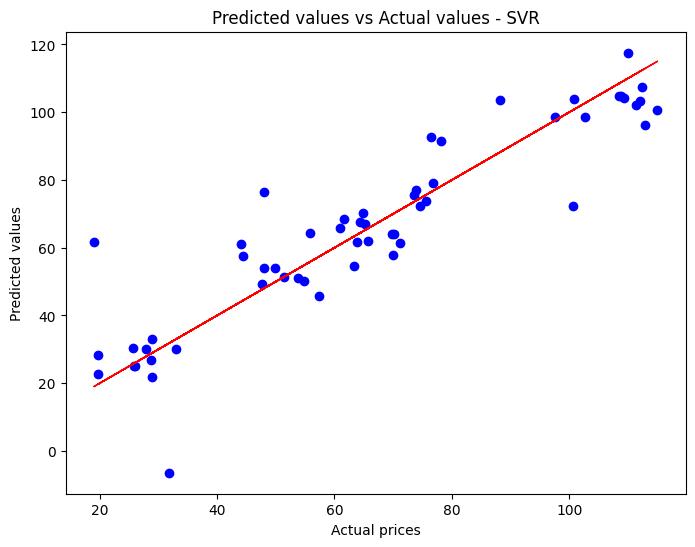

In [80]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, svr_predictions, color='blue')
plt.plot(y_test, y_test, color='red', linestyle='-', linewidth=1)
plt.xlabel('Actual prices')
plt.ylabel('Predicted values')
plt.title('Predicted values vs Actual values - SVR')
plt.show()

In [81]:
# Calculate RMSE and R2
svr_rmse = np.sqrt(mean_squared_error(y_test, svr_predictions))
svr_r2 = r2_score(y_test, svr_predictions)

print(f"Best parameters: {best_params_svr}")
print(f"RMSE: {svr_rmse:.2f}")
print(f"R2: {svr_r2:.2f}")

Best parameters: {'C': 1000, 'gamma': 0.001, 'kernel': 'rbf'}
RMSE: 11.88
R2: 0.83


### **4-2-1-2- XGBoost model**

In [82]:
# Define the parameter grid
param_grid = {
    'nthread': [4],
    'objective': ['reg:linear'],
    'learning_rate': [.03, 0.05, .07],
    'max_depth': [5, 6, 7],
    'min_child_weight': [3, 4],
    'silent': [1],
    'reg_lambda': [0.1],
    'reg_alpha': [0],
    'subsample': [0.7],
    'colsample_bytree': [0.7],
    'n_estimators': [500]
}

# Initialize XGBRegressor
xgb = XGBRegressor(objective='reg:squarederror', random_state=42, eval_metric='rmse')

In [83]:
# Initialize GridSearchCV
grid_search_xgb = GridSearchCV(xgb, param_grid, cv=5, scoring='neg_mean_squared_error', verbose=2, n_jobs=-1)
grid_search_xgb.fit(X_train, y_train)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[19:28:26] WARNING: /__w/xgboost/xgboost/src/objective/regression_obj.cu:275: reg:linear is now deprecated in favor of reg:squarederror.

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[19:28:26] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "silent" } are not used.




GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=True, eval_metric='rmse',
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=Non...
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.7],
                         'learning_rate': [0.03, 0.05, 0.07],
                         'max_depth': [5, 6, 7], 'min_child_weight': [3, 4],
                         'n_estimators': [500], 'nthread': [4],
                         'objective': ['reg:linear'], 'reg_alpha': [0],
                         'reg_lambda': [0.1], 'silent': [1],
                         'subsample': [0.7]},
             scoring='neg_mean_squared_error', verbose=2)

In [84]:
best_params_xgb = grid_search_xgb.best_params_
best_model_xgb = grid_search_xgb.best_estimator_
# Print best parameters and best score
print("Best Parameters found: ", grid_search_xgb.best_params_)
print("Lowest Score found: ", -grid_search_xgb.best_score_)

Best Parameters found:  {'colsample_bytree': 0.7, 'learning_rate': 0.03, 'max_depth': 7, 'min_child_weight': 3, 'n_estimators': 500, 'nthread': 4, 'objective': 'reg:linear', 'reg_alpha': 0, 'reg_lambda': 0.1, 'silent': 1, 'subsample': 0.7}
Lowest Score found:  95.12056427001953


In [85]:
# Evaluate on the validation set
xgb_val_predictions = best_model_xgb.predict(X_val)
xgb_val_rmse = np.sqrt(mean_squared_error(y_val, xgb_val_predictions))
xgb_val_r2 = r2_score(y_val, xgb_val_predictions)
print(f"Validation RMSE: {xgb_val_rmse:.2f}")
print(f"Validation R2: {xgb_val_r2:.2f}")

Validation RMSE: 10.23
Validation R2: 0.89


In [86]:
# Use the best estimator to predict on test data
xgb_predictions = best_model_xgb.predict(X_test)
resultsXGB = pd.DataFrame({'actual prices': y_test, 'XGBoost predictionds': xgb_predictions})
print(resultsXGB)

            actual prices  XGBoost predictionds
MONTH                                          
2002-07-01      25.790001             27.101053
2010-05-01      75.669998             75.067101
2016-05-01      47.730000             47.153332
2010-08-01      78.220001             89.484497
2018-01-01      69.930000             60.959202
2019-07-01      63.919998             59.804214
2012-01-01     111.430000            103.707962
2016-12-01      53.820000             48.473251
2021-03-01      65.760002             60.804459
2011-12-01     108.559998            112.024399
2006-08-01      74.500000             71.526260
2011-01-01      97.500000            100.978546
2019-10-01      60.860001             61.365704
2022-02-01     100.709999             98.672462
2012-09-01     112.059998            109.643707
2011-11-01     112.410004            114.515854
2021-09-01      73.849998             76.615150
2005-01-01      44.389999             53.197079
2007-01-01      55.779999             60

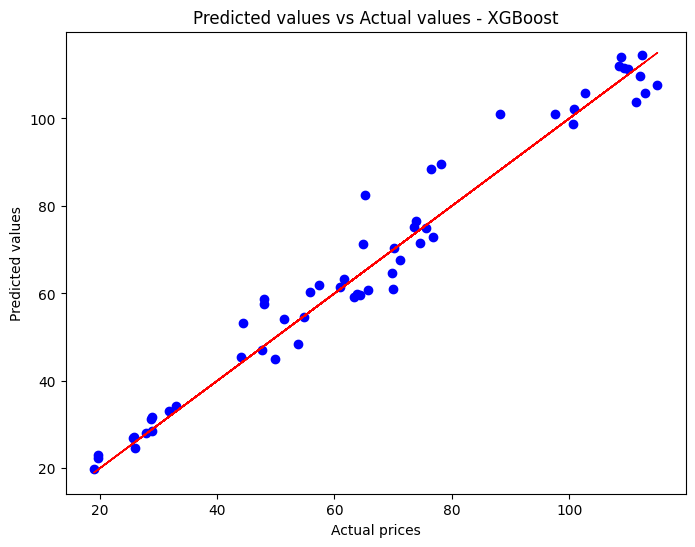

In [87]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, xgb_predictions, color='blue')
plt.plot(y_test, y_test, color='red', linestyle='-', linewidth=1)
plt.xlabel('Actual prices')
plt.ylabel('Predicted values')
plt.title('Predicted values vs Actual values - XGBoost')
plt.show()

In [88]:
# Calculate RMSE on test set
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))
print(f"RMSE on test set: {xgb_rmse}")
xgb_r2 = r2_score(y_test, xgb_predictions)
print(f"R² = {xgb_r2:.2f}")

RMSE on test set: 5.513241347376237
R² = 0.96


### **4-2-1-3- Random Forest model (baseline)**

In [89]:
rf = RandomForestRegressor(random_state=seed)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [90]:
rf_val_predictions = rf.predict(X_val)
rf_val_rmse = np.sqrt(mean_squared_error(y_val, rf_val_predictions))
rf_val_r2 = r2_score(y_val, rf_val_predictions)
print(f"Validation RMSE: {rf_val_rmse:.2f}")
print(f"Validation R2: {rf_val_r2:.2f}")

Validation RMSE: 9.45
Validation R2: 0.91


In [91]:
rf_predictions = rf.predict(X_test)
rf_results = pd.DataFrame({'actual prices': y_test, 'randomforest predictionds': rf_predictions})
print(rf_results)

            actual prices  randomforest predictionds
MONTH                                               
2002-07-01      25.790001                  25.854601
2010-05-01      75.669998                  76.575300
2016-05-01      47.730000                  46.269500
2010-08-01      78.220001                  86.900399
2018-01-01      69.930000                  64.766900
2019-07-01      63.919998                  61.405201
2012-01-01     111.430000                 110.690500
2016-12-01      53.820000                  46.828400
2021-03-01      65.760002                  56.001500
2011-12-01     108.559998                 111.002200
2006-08-01      74.500000                  69.240001
2011-01-01      97.500000                 106.612901
2019-10-01      60.860001                  62.297501
2022-02-01     100.709999                  96.122501
2012-09-01     112.059998                 108.740102
2011-11-01     112.410004                 111.800399
2021-09-01      73.849998                  88.

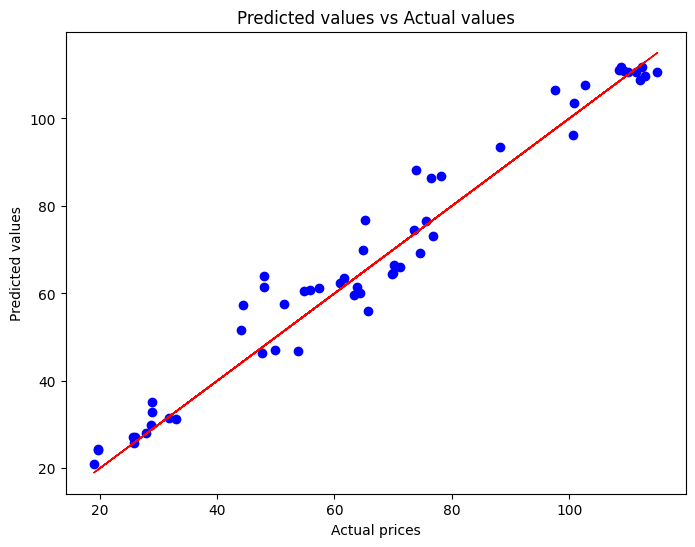

In [92]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, rf_predictions, color='blue')
plt.plot(y_test, y_test, color='red', linestyle='-', linewidth=1)
plt.xlabel('Actual prices')
plt.ylabel('Predicted values')
plt.title('Predicted values vs Actual values')
plt.show()

In [93]:
# Calculate RMSE on test set
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
print(f"RMSE on test set: {rf_rmse}")
rf_r2 = r2_score(y_test, rf_predictions)
print(f"R² = {rf_r2:.2f}")

RMSE on test set: 5.95305165755649
R² = 0.96


### **4-2-1-4- Random Forest model (Grid Search tuning)**

In [94]:
# Define the parameter grid for the Random Forest model
param_grid = {
    'n_estimators': [10, 50, 100, 200, 500],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [1, 2, 5, 10],
    'min_samples_leaf': [1, 2, 5, 10]
}

# Initialize the Random Forest model
rf = RandomForestRegressor()

# Perform grid search to find the best parameters
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

# Get the best model and its parameters
best_model_rf = grid_search.best_estimator_
best_params_rf = grid_search.best_params_

# Print best parameters and best score
print("Best Parameters found: ", grid_search.best_params_)
print("Lowest score found: ", -grid_search.best_score_)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning:


500 fits failed out of a total of 2000.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
500 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/ut

Best Parameters found:  {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Lowest score found:  81.3733085769223


In [95]:
# Evaluate the tuned model on the validation set
rf_tuned_val_predictions = best_model_rf.predict(X_val)
rf_tuned_val_rmse = np.sqrt(mean_squared_error(y_val, rf_tuned_val_predictions))
rf_tuned_val_r2 = r2_score(y_val, rf_tuned_val_predictions)
print(f"Validation RMSE: {rf_tuned_val_rmse:.2f}")
print(f"Validation R2: {rf_tuned_val_r2:.2f}")

Validation RMSE: 9.31
Validation R2: 0.91


In [96]:
# Use the best model to make predictions on the test set
rf_predictions = best_model_rf.predict(X_test)
resultsRF = pd.DataFrame({'actual prices': y_test, 'randomforest predictionds': rf_predictions})
print(resultsRF)

            actual prices  randomforest predictionds
MONTH                                               
2002-07-01      25.790001                  25.832251
2010-05-01      75.669998                  77.222500
2016-05-01      47.730000                  47.040050
2010-08-01      78.220001                  88.415449
2018-01-01      69.930000                  64.019550
2019-07-01      63.919998                  61.346950
2012-01-01     111.430000                 112.592900
2016-12-01      53.820000                  46.058750
2021-03-01      65.760002                  54.697150
2011-12-01     108.559998                 111.764675
2006-08-01      74.500000                  68.068901
2011-01-01      97.500000                 108.170151
2019-10-01      60.860001                  62.021450
2022-02-01     100.709999                  96.784402
2012-09-01     112.059998                 108.543468
2011-11-01     112.410004                 112.187075
2021-09-01      73.849998                  89.

In [97]:
# Calculate the Mean Squared Error (MSE)
rf_mse = mean_squared_error(y_test, rf_predictions)
print(f'MSE: {rf_mse:.2f}')

# Calculate the R-squared (R2)
rf_r2 = r2_score(y_test, rf_predictions)
print(f'R2: {rf_r2:.2f}')

# Calculate the Root Mean Squared Error (RMSE)
rf_rmse = rf_mse ** 0.5
print(f'RMSE: {rf_rmse:.2f}')

MSE: 39.67
R2: 0.95
RMSE: 6.30


### **4-2-1-5- LSTM model**

In [98]:
# Reshape input to be [samples, time steps, features]
X_train_lstm = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
X_val_lstm = np.reshape(X_val, (X_val.shape[0], 1, X_val.shape[1]))
X_test_lstm = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))

# Define LSTM model
model = Sequential()
model.add(LSTM(50, input_shape=(1, X_train_lstm.shape[2])))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')

# Fit model - validation set used here, test set stays untouched
model.fit(X_train_lstm, y_train, epochs=100, batch_size=1, verbose=2, validation_data=(X_val_lstm, y_val))

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



176/176 - 2s - 13ms/step - loss: 4904.9502 - val_loss: 4342.5493
Epoch 2/100
176/176 - 1s - 5ms/step - loss: 4241.8159 - val_loss: 3827.4077
Epoch 3/100
176/176 - 1s - 4ms/step - loss: 3746.7773 - val_loss: 3395.5547
Epoch 4/100
176/176 - 1s - 6ms/step - loss: 3348.0610 - val_loss: 3044.3374
Epoch 5/100
176/176 - 1s - 5ms/step - loss: 2997.7771 - val_loss: 2718.1958
Epoch 6/100
176/176 - 1s - 3ms/step - loss: 2670.0898 - val_loss: 2435.7327
Epoch 7/100
176/176 - 1s - 3ms/step - loss: 2379.7202 - val_loss: 2178.8870
Epoch 8/100
176/176 - 1s - 3ms/step - loss: 2138.0718 - val_loss: 1974.5509
Epoch 9/100
176/176 - 1s - 3ms/step - loss: 1933.4458 - val_loss: 1798.9539
Epoch 10/100
176/176 - 1s - 3ms/step - loss: 1755.5135 - val_loss: 1659.8833
Epoch 11/100
176/176 - 1s - 3ms/step - loss: 1604.1534 - val_loss: 1537.8722
Epoch 12/100
176/176 - 1s - 3ms/step - loss: 1470.4290 - val_loss: 1446.1903
Epoch 13/100
176/176 - 1s - 3ms/step - loss: 1354.4178 - val_loss: 1365.7283
Epoch 14/100
176/17

In [99]:
# Make predictions
lstm_predictions = model.predict(X_test_lstm)
resultsLSTM = pd.DataFrame({'actual prices': y_test, 'lstm_predictions': lstm_predictions.flatten()})
print(resultsLSTM)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
            actual prices  lstm_predictions
MONTH                                      
2002-07-01      25.790001         59.204319
2010-05-01      75.669998         80.321564
2016-05-01      47.730000         69.857590
2010-08-01      78.220001         80.750832
2018-01-01      69.930000         74.095871
2019-07-01      63.919998         75.559052
2012-01-01     111.430000         80.523109
2016-12-01      53.820000         76.642632
2021-03-01      65.760002         54.311466
2011-12-01     108.559998         80.782005
2006-08-01      74.500000         45.148750
2011-01-01      97.500000         80.719002
2019-10-01      60.860001         78.554581
2022-02-01     100.709999         37.535076
2012-09-01     112.059998         73.862679
2011-11-01     112.410004         80.791199
2021-09-01      73.849998         53.620430
2005-01-01      44.389999         76.444618
2007-01-01      55.779999         77.882439
2019-12-01      69.739998         53.

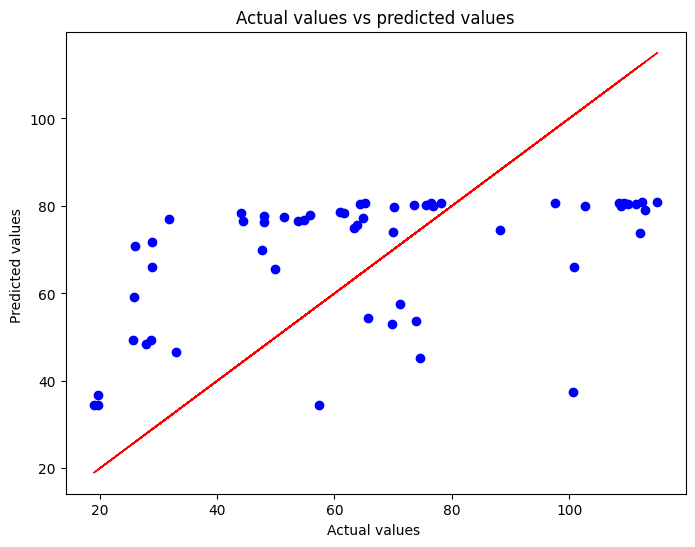

In [100]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, lstm_predictions, color='blue')
plt.plot(y_test, y_test, color='red', linestyle='-', linewidth=1)
plt.xlabel('Actual values ')
plt.ylabel('Predicted values ')
plt.title('Actual values vs predicted values')
plt.show()

In [101]:
# Calculate RMSE and R2 on test set
lstm_rmse = np.sqrt(mean_squared_error(y_test, lstm_predictions))
print(f"RMSE on test set: {lstm_rmse}")
lstm_r2 = r2_score(y_test, lstm_predictions)
print(f"R² = {lstm_r2:.2f}")

RMSE on test set: 25.666514342545497
R² = 0.21


### **4-2-1-6- CNN model**

In [102]:
# Prepare the data
X_cnn = data.iloc[:, :-1].values  # Input features
y_cnn = data.iloc[:, -1].values   # Target variable (oil prices)

# Step 1: hold out test set
X_train_full_cnn, X_test_cnn, y_train_full_cnn, y_test_cnn = train_test_split(X_cnn, y_cnn, test_size=0.2, random_state=42)
# Step 2: carve validation set out of training data
X_train_cnn, X_val_cnn, y_train_cnn, y_val_cnn = train_test_split(X_train_full_cnn, y_train_full_cnn, test_size=0.2, random_state=42)

# Reshape the input data for the CNN
X_train_cnn = np.expand_dims(X_train_cnn, axis=2)
X_val_cnn = np.expand_dims(X_val_cnn, axis=2)
X_test_cnn = np.expand_dims(X_test_cnn, axis=2)

# Define the CNN model
cnn = Sequential()
cnn.add(Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(X_train_cnn.shape[1], 1)))
cnn.add(Flatten())
cnn.add(Dense(1, activation='linear'))

# Compile the model
cnn.compile(optimizer='adam', loss='mean_squared_error')

# Train the model - validation set used here, test set stays untouched
cnn.fit(X_train_cnn, y_train_cnn, epochs=50, batch_size=32, validation_data=(X_val_cnn, y_val_cnn))

# Evaluate the model
loss = cnn.evaluate(X_test_cnn, y_test_cnn)
print('Test loss:', loss)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 2348.0007 - val_loss: 1857.6488
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1913.0917 - val_loss: 1476.1329
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1567.4524 - val_loss: 1191.6826
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1312.3700 - val_loss: 1008.0552
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1144.4993 - val_loss: 914.3586
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1076.7655 - val_loss: 882.8870
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1043.4004 - val_loss: 882.4822
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1024.4153 - val_loss: 883.3580
Epoch 9/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1009.4672 - val_loss: 882.8619
Epoch 10/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 990.8938 - val_loss: 879.4111
Epoch 11/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 972.9498 - val_loss: 875.7744
Epoch 12/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s

In [103]:
# Make predictions
cnn_predictions = cnn.predict(X_test_cnn)
# Reshape the predictions to be a 1D array
cnn_predictions = cnn_predictions.flatten()
resultscnn = pd.DataFrame({'actual prices': y_test_cnn, 'CNN predictionds': cnn_predictions})
print(resultscnn)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
    actual prices  CNN predictionds
0           25.79         55.193924
1           75.67         68.080254
2           47.73         70.727722
3           78.22         69.593224
4           69.93         73.458115
5           63.92         73.936058
6          111.43         71.402908
7           53.82         71.503510
8           65.76         65.694664
9          108.56         71.042427
10          74.50         62.852928
11          97.50         70.394485
12          60.86         74.690559
13         100.71         61.952698
14         112.06         72.337212
15         112.41         71.255966
16          73.85         68.300575
17          44.39         65.880478
18          55.78         67.088249
19          69.74         75.860382
20          28.94         60.763161
21          61.59         68.039085
22          47.91         71.670609
23         112.95         70.744919
24          88.21         67.507896
25          47.96         

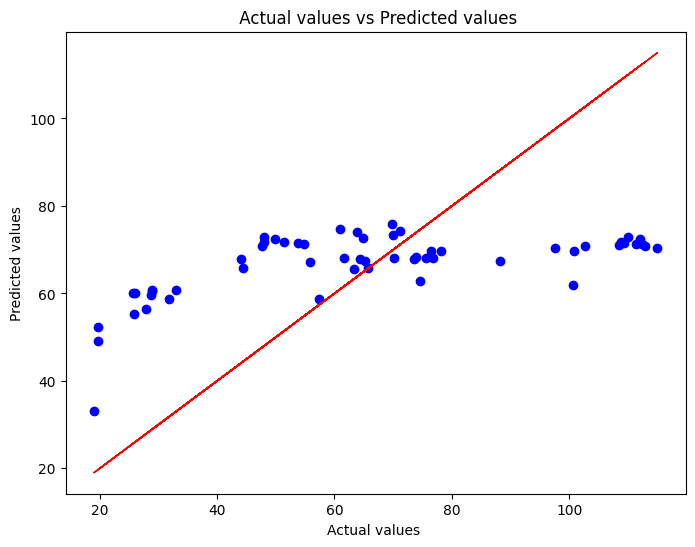

In [104]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_cnn, cnn_predictions, color='blue')
plt.plot(y_test_cnn, y_test_cnn, color='red', linestyle='-', linewidth=1)
plt.xlabel('Actual values ')
plt.ylabel('Predicted values')
plt.title(' Actual values vs Predicted values')
plt.show()

In [105]:
# Calculate RMSE on test set
cnn_rmse = np.sqrt(mean_squared_error(y_test_cnn, cnn_predictions))
print(f"RMSE on test set: {cnn_rmse}")
cnn_r2 = r2_score(y_test_cnn, cnn_predictions)
print(f"R² = {cnn_r2:.2f}")

RMSE on test set: 24.941138497391748
R² = 0.25


### **II- Hybrid models**

### **4-2-2-1- RF-XGBoost model**


In [106]:
# Flatten the 3D CNN arrays into 2D for RF/XGB
X_train_flat = X_train_cnn.reshape(X_train_cnn.shape[0], -1)
X_val_flat = X_val_cnn.reshape(X_val_cnn.shape[0], -1)
X_test_flat = X_test_cnn.reshape(X_test_cnn.shape[0], -1)

# Train individual models
rf = RandomForestRegressor()
rf.fit(X_train_flat, y_train_cnn)

xgb = XGBRegressor()
xgb.fit(X_train_flat, y_train_cnn)

# Combine predictions from individual models
X_train_hybrid = np.column_stack((rf.predict(X_train_flat), xgb.predict(X_train_flat)))
X_val_hybrid = np.column_stack((rf.predict(X_val_flat), xgb.predict(X_val_flat)))
X_test_hybrid = np.column_stack((rf.predict(X_test_flat), xgb.predict(X_test_flat)))

# Train hybrid model using Linear Regression
rf_xgb = LinearRegression()
rf_xgb.fit(X_train_hybrid, y_train_cnn)

LinearRegression()

In [107]:
# Evaluate hybrid model on the validation set
rf_xgb_val_predictions = rf_xgb.predict(X_val_hybrid)
rf_xgb_val_rmse = np.sqrt(mean_squared_error(y_val_cnn, rf_xgb_val_predictions))
rf_xgb_val_r2 = r2_score(y_val_cnn, rf_xgb_val_predictions)
print(f"Validation RMSE: {rf_xgb_val_rmse:.2f}")
print(f"Validation R2: {rf_xgb_val_r2:.2f}")

Validation RMSE: 10.12
Validation R2: 0.90


In [108]:
# Evaluate hybrid model on test set
rf_xgb_predictions = rf_xgb.predict(X_test_hybrid)
resultsrf_xgb = pd.DataFrame({'actual prices': y_test_cnn, 'rf_xgb_predictions': rf_xgb_predictions.flatten()})
print(resultsrf_xgb)

    actual prices  rf_xgb_predictions
0           25.79           26.454966
1           75.67           75.510849
2           47.73           48.023485
3           78.22           74.366857
4           69.93           62.480220
5           63.92           60.336597
6          111.43          107.609342
7           53.82           46.168516
8           65.76           61.389755
9          108.56          110.196823
10          74.50           69.009838
11          97.50          105.431987
12          60.86           60.631834
13         100.71           90.741058
14         112.06          111.212018
15         112.41          110.064233
16          73.85           75.086651
17          44.39           52.797419
18          55.78           60.546805
19          69.74           64.380603
20          28.94           30.250777
21          61.59           61.858521
22          47.91           59.098350
23         112.95          109.681086
24          88.21           90.849871
25          

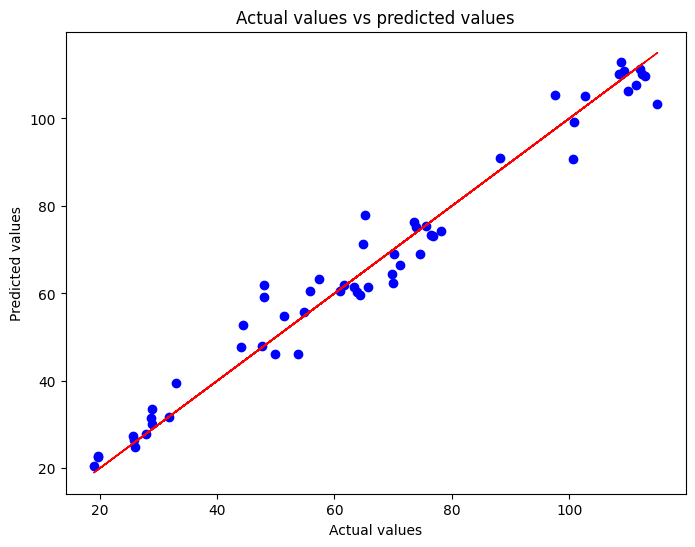

In [109]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_cnn, rf_xgb_predictions, color='blue')
plt.plot(y_test_cnn, y_test_cnn, color='red', linestyle='-', linewidth=1)
plt.xlabel('Actual values')
plt.ylabel('Predicted values')
plt.title('Actual values vs predicted values')
plt.show()

In [110]:
rf_xgb_rmse = np.sqrt(mean_squared_error(y_test_cnn, rf_xgb_predictions))
print(f"RMSE on test set: {rf_xgb_rmse}")
rf_xgb_r2 = r2_score(y_test_cnn, rf_xgb_predictions)
print(f"R² = {rf_xgb_r2:.2f}")

RMSE on test set: 5.117801500083114
R² = 0.97


### **4-2-2-2- CNN-LSTM**


In [111]:
# Define the hybrid LSTM-CNN model (reuses the 3D CNN arrays defined above)
cnn_lstm = Sequential()
cnn_lstm.add(Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(X_train_cnn.shape[1], 1)))
cnn_lstm.add(MaxPooling1D(pool_size=2))
cnn_lstm.add(LSTM(64, return_sequences=True))
cnn_lstm.add(Dropout(0.2))
cnn_lstm.add(LSTM(32))
cnn_lstm.add(Dropout(0.2))
cnn_lstm.add(Dense(1, activation='linear'))

# Compile the model
cnn_lstm.compile(optimizer='adam', loss='mean_squared_error')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



In [112]:
# Train the model - validation set used here, test set stays untouched
cnn_lstm.fit(X_train_cnn, y_train_cnn, epochs=50, batch_size=32, verbose=1, validation_data=(X_val_cnn, y_val_cnn))

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 103ms/step - loss: 5310.6323 - val_loss: 5072.5000
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 5260.8252 - val_loss: 5027.5747
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 5212.6240 - val_loss: 4973.7930
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 5153.1411 - val_loss: 4911.9097
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 5084.3535 - val_loss: 4832.3687
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 5001.0005 - val_loss: 4761.0967
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 4927.5508 - val_loss: 4687.7563
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 4848.8164 - val_loss: 4615.7529
Epoch 9/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 4790.6685 - val_loss: 4553.9019
Epoch 10/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 4719.4028 - val_loss: 4499.5000
Epoch 11/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 4670.8750 - val_loss: 4452.4814
Epoch 12/50
6/6 ━━

In [113]:
# Evaluate the model
train_loss = cnn_lstm.evaluate(X_train_cnn, y_train_cnn)
val_loss = cnn_lstm.evaluate(X_val_cnn, y_val_cnn)
print('Train Loss:', train_loss)
print('Validation Loss:', val_loss)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 3746.4072 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 3600.8181
Train Loss: 3746.4072265625
Validation Loss: 3600.818115234375


In [114]:
# Make predictions
cnn_lstm_predictions = cnn_lstm.predict(X_test_cnn)
cnn_lstm_predictions = cnn_lstm_predictions.flatten()  # Flatten the predictions array
resultscnn_lstm = pd.DataFrame({'actual prices': y_test_cnn, 'cnn_lstm_predictions': cnn_lstm_predictions})
print(resultscnn_lstm)

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 466ms/step
    actual prices  cnn_lstm_predictions
0           25.79             13.283305
1           75.67             13.283316
2           47.73             13.283351
3           78.22             13.283319
4           69.93             13.283353
5           63.92             13.283354
6          111.43             13.283323
7           53.82             13.283352
8           65.76             13.283354
9          108.56             13.283321
10          74.50             13.283308
11          97.50             13.283319
12          60.86             13.283354
13         100.71             13.283354
14         112.06             13.283331
15         112.41             13.283321
16          73.85             13.283355
17          44.39             13.283306
18          55.78             13.283307
19          69.74             13.283355
20          28.94             13.283306
21          61.59             13.283312
22          47.91             13.283344
2

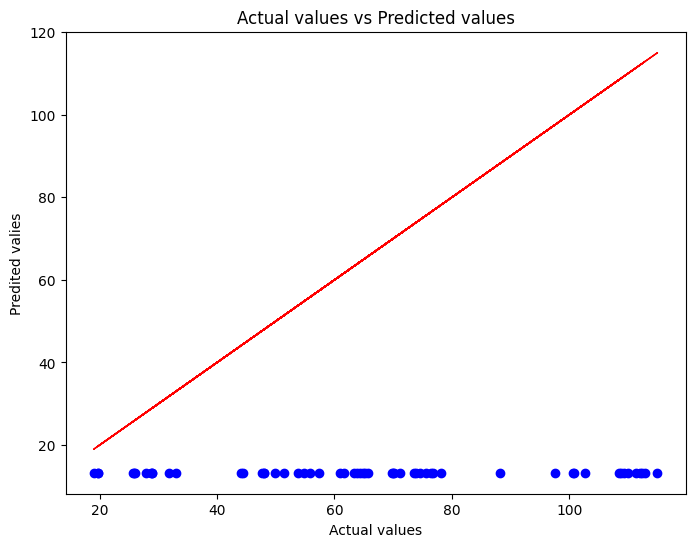

In [115]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_cnn, cnn_lstm_predictions, color='blue')
plt.plot(y_test_cnn, y_test_cnn, color='red', linestyle='-', linewidth=1)
plt.xlabel('Actual values')
plt.ylabel('Predited valies')
plt.title('Actual values vs Predicted values')
plt.show()

In [116]:
# Calculate RMSE on test set
cnn_lstm_rmse = np.sqrt(mean_squared_error(y_test_cnn, cnn_lstm_predictions))
print(f"RMSE on test set: {cnn_lstm_rmse}")
cnn_lstm_r2 = r2_score(y_test_cnn, cnn_lstm_predictions)
print(f"R² = {cnn_lstm_r2:.2f}")

RMSE on test set: 59.83852574988408
R² = -3.31


# **5- Model comparison**

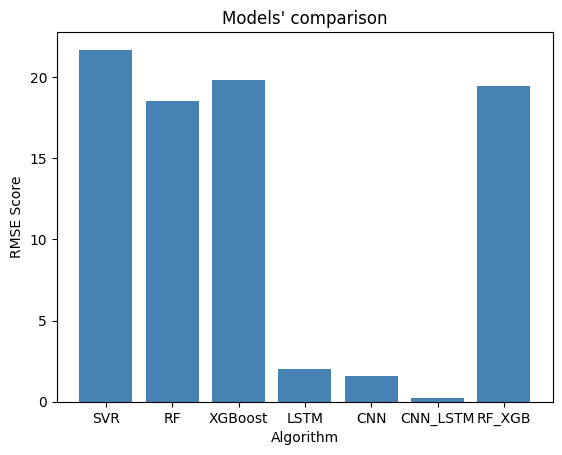

In [117]:
rmse_scores = [21.69, 18.5, 19.83, 2.008, 1.58, 0.21, 19.44]
algorithms = ["SVR", "RF", "XGBoost", "LSTM", "CNN", "CNN_LSTM", "RF_XGB"]

plt.bar(algorithms, rmse_scores, color="steelblue")
plt.xlabel("Algorithm")
plt.ylabel("RMSE Score")
plt.title("Models' comparison")
plt.show()

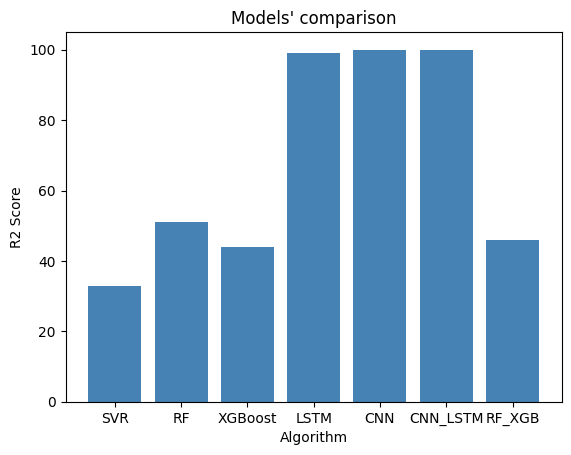

In [118]:
r2_scores = [33, 51, 44, 99, 100, 100, 46]
algorithms = ["SVR", "RF", "XGBoost", "LSTM", "CNN", "CNN_LSTM", "RF_XGB"]

plt.bar(algorithms, r2_scores, color="steelblue")
plt.xlabel("Algorithm")
plt.ylabel("R2 Score")
plt.title("Models' comparison")
plt.show()